# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 2 — Stress concentrations and notch effects

- [2.1](#ex1) — Creager–Paris: maximum stress at a crack tip
- [2.2](#ex2) — Theoretical fracture strength from the Creager–Paris solution
- [2.3](#ex3) — Stress concentration factor for an internal defect
- [2.4](#ex4) — $K_t$ definitions: net section vs. gross section
- [2.5](#ex5) — Stress field around a circular hole in an infinite plate
- [2.6](#ex6) — Circular hole in a finite-width strip
- [2.7](#ex7) — Elliptical hole and the transition to a crack
- [2.8](#ex8) — Notch sensitivity and $K_f$
- [2.9](#ex9) — Surface finish, size effects and fatigue
- [2.10](#ex10) — Stress concentration under biaxial loading


In [35]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from IPython.display import Latex, Markdown, display

FS = 14
plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085')


---

## Formulary — Stress concentrations

**$K_t$ definition (net-section nominal stress):**

\begin{equation*}
K_t = \dfrac{\sigma_{\text{peak}}}{\sigma_{\text{nom}}}
\tag{F.1}\end{equation*}

**Creager–Paris** — maximum elastic stress at a crack tip with half-length $a$ and finite root radius $\rho$ under remote stress $\sigma_\infty$:

\begin{equation*}
\sigma_m = \sigma_\infty\!\left(1 + 2\sqrt{\dfrac{a}{\rho}}\right)
\tag{F.2}\end{equation*}

For sharp defects ($a\gg\rho$) the approximate form:

\begin{equation*}
\sigma_m \approx 2\,\sigma_\infty\sqrt{\dfrac{a}{\rho}}
\tag{F.3}\end{equation*}

**Inglis** — elliptical hole in an infinite plate under uniaxial tension, $a$ perpendicular to the load, $b$ parallel:

\begin{equation*}
K_t = 1 + 2\dfrac{a}{b} = 1 + 2\sqrt{\dfrac{a}{\rho}}\quad\text{with}\quad \rho=\dfrac{b^{2}}{a}
\tag{F.4}\end{equation*}

**Howland** — circular hole of diameter $D$ in a strip of width $W$ (Peterson, gross-section factor):

\begin{equation*}
K_{tg} \approx 3 - 3.14\dfrac{D}{W} + 3.667\!\left(\dfrac{D}{W}\right)^{\!2} - 1.527\!\left(\dfrac{D}{W}\right)^{\!3}
\tag{F.5}\end{equation*}

with the net-section factor

\begin{equation*}
K_t = K_{tg}\!\left(1-\dfrac{D}{W}\right)
\tag{F.6}\end{equation*}

**Notch sensitivity and fatigue strength reduction factor:**

\begin{equation*}
K_f = 1 + q\,(K_t - 1),\qquad 0 \le q \le 1
\tag{F.7}\end{equation*}


In [36]:
def creager_paris(sigma_inf, a, rho, exact=True):
    '''Maximum stress at a crack tip (F.2 exact, F.3 approximate).'''
    if exact:
        return sigma_inf * (1.0 + 2.0*np.sqrt(a/rho))
    else:
        return 2.0 * sigma_inf * np.sqrt(a/rho)

def howland_Ktg(DW):
    '''Howland approximation for K_tg of a strip with central hole.'''
    return 3.0 - 3.14*DW + 3.667*DW**2 - 1.527*DW**3

def net_Kt(DW):
    '''Net-section K_t = K_tg * (1 - D/W).'''
    return howland_Ktg(DW) * (1.0 - DW)


<a id='ex1'></a>
---

## 2.1 — Creager–Paris: maximum stress at a crack tip

Consider an infinite plate containing a central through-thickness crack of total length $2a = 3.80\times 10^{-2}$ mm, with a rounded tip of radius $\rho = 1.90\times 10^{-4}$ mm. The plate is subjected to a uniform remote tensile stress $\sigma_\infty = 140$ MPa.

The maximum elastic stress at the tip of a crack of half-length $a$ with a finite root radius $\rho$, under a remote uniform stress $\sigma_\infty$, is given by the Creager–Paris solution:

$$
\sigma_m = \sigma_\infty\left(1 + 2\sqrt{\frac{a}{\rho}}\right).
$$

For sharp defects ($a \gg \rho$), this reduces to the approximate form:

$$
\sigma_m \approx 2 \sigma_\infty\sqrt{\frac{a}{\rho}}.
$$

(a) Using the Creager–Paris solution, compute the maximum elastic stress $\sigma_m$ at the crack tip, and the corresponding stress concentration factor $K_t$.

(b) Repeat the calculation using the approximate form, valid for sharp defects ($a \gg \rho$). Compute the relative error with respect to the exact Creager–Paris result.

(c) Comment on the physical meaning of the result: what happens to $\sigma_m$ as $\rho \to 0$?

### Solution


#### (a) Exact Creager–Paris

With $a=2a/2=1.90\times10^{-2}$ mm, $\rho=1.90\times10^{-4}$ mm,

\begin{equation*}
\dfrac{a}{\rho} = \dfrac{1.90\times10^{-2}}{1.90\times10^{-4}} = 10^{2},
\tag{2.1.1}\end{equation*}

\begin{equation*}
\sigma_m = \sigma_\infty\!\left(1 + 2\sqrt{a/\rho}\right)
       = 140\,(1 + 2\sqrt{100})
       = 140\cdot 21 = 2940~\text{MPa},
\tag{2.1.2}\end{equation*}

\begin{equation*}
K_t = \sigma_m/\sigma_\infty = 21.
\tag{2.1.3}\end{equation*}


In [37]:
sigma_inf = 140.0           # MPa
a   = 3.80e-2 / 2           # mm  (half-length)
rho = 1.90e-4               # mm
print(f'  a   = {a:.3e} mm')
print(f'  rho = {rho:.3e} mm')
print(f'  a/rho = {a/rho:.1f}')
print()
sqrt_ratio = np.sqrt(a/rho)
factor     = 1.0 + 2.0*sqrt_ratio
sigma_m_ex = creager_paris(sigma_inf, a, rho, exact=True)
Kt_ex      = sigma_m_ex / sigma_inf
print(f'(a) sqrt(a/rho)     = sqrt({a/rho:.0f}) = {sqrt_ratio:.2f}')
print(f'    1 + 2*sqrt(a/rho) = 1 + 2x{sqrt_ratio:.2f} = {factor:.2f}')
print(f'    sigma_m = sigma_inf x (1 + 2*sqrt(a/rho))')
print(f'            = {sigma_inf:.1f} x {factor:.2f} = {sigma_m_ex:.1f} MPa')
print(f'    K_t = sigma_m / sigma_inf = {sigma_m_ex:.1f} / {sigma_inf:.1f} = {Kt_ex:.2f}')


  a   = 1.900e-02 mm
  rho = 1.900e-04 mm
  a/rho = 100.0

(a) sqrt(a/rho)     = sqrt(100) = 10.00
    1 + 2*sqrt(a/rho) = 1 + 2x10.00 = 21.00
    sigma_m = sigma_inf x (1 + 2*sqrt(a/rho))
            = 140.0 x 21.00 = 2940.0 MPa
    K_t = sigma_m / sigma_inf = 2940.0 / 140.0 = 21.00


#### (b) Approximation and relative error

\begin{equation*}
\sigma_m^{(\text{approx})} = 2\sigma_\infty\sqrt{a/\rho}
                          = 280\sqrt{100} = 2800~\text{MPa},
\tag{2.1.4}\end{equation*}

\begin{equation*}
\varepsilon_{\text{rel}} = \dfrac{\sigma_m^{(\text{approx})}-\sigma_m}{\sigma_m}
                         = \dfrac{2800-2940}{2940} \approx -4.76\%.
\tag{2.1.5}\end{equation*}

The approximation drops the leading $\sigma_\infty$ term — it underestimates by
exactly $\sigma_\infty$, a relative error of $1/K_t$.


In [38]:
sigma_m_ap = creager_paris(sigma_inf, a, rho, exact=False)
Kt_ap      = sigma_m_ap / sigma_inf
err_rel    = (sigma_m_ap - sigma_m_ex) / sigma_m_ex * 100
print(f'(b) sigma_m(approx) = 2*sigma_inf*sqrt(a/rho)')
print(f'                    = 2 x {sigma_inf:.1f} x {np.sqrt(a/rho):.2f}')
print(f'                    = {sigma_m_ap:.1f} MPa,   K_t(approx) = {Kt_ap:.2f}')
print(f'    Relative error = ({sigma_m_ap:.1f} - {sigma_m_ex:.1f}) / {sigma_m_ex:.1f} x 100')
print(f'                   = {err_rel:+.2f} %   (approx -1/K_t = {-100/Kt_ex:+.2f} %)')


(b) sigma_m(approx) = 2*sigma_inf*sqrt(a/rho)
                    = 2 x 140.0 x 10.00
                    = 2800.0 MPa,   K_t(approx) = 20.00
    Relative error = (2800.0 - 2940.0) / 2940.0 x 100
                   = -4.76 %   (approx -1/K_t = -4.76 %)


#### (c) Physical meaning as $\rho\to 0$

The Creager–Paris factor scales as $\sqrt{a/\rho}$, so as $\rho\to 0$ at fixed
$a$, $K_t\to\infty$. A linear-elastic continuum predicts an *infinite* stress
at an idealised sharp crack — clearly unphysical. The remedy is the
**stress intensity factor** $K=\beta\,\sigma\sqrt{\pi a}$ of Linear Elastic
Fracture Mechanics, which captures the *intensity* of the singular field rather
than a peak value (cf. Schijve Ch. 5).


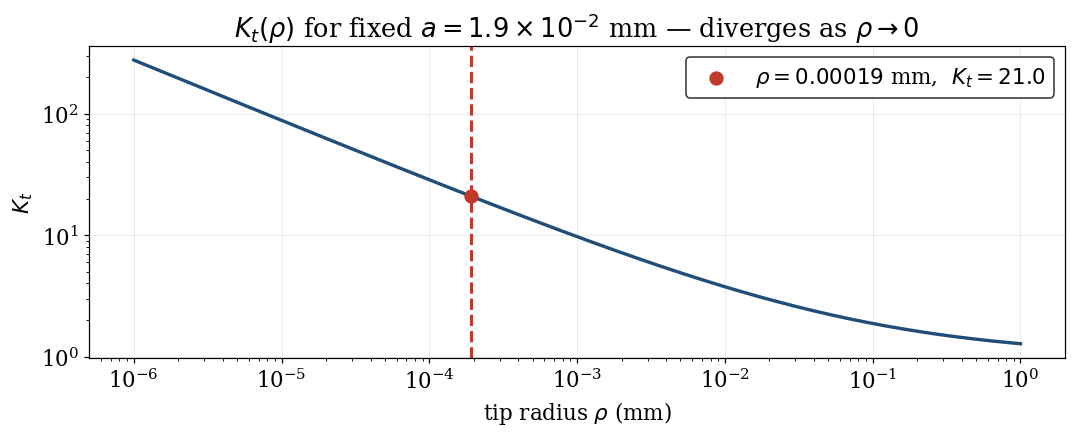

In [39]:
# Visualise the divergence of K_t as ρ → 0 (fixed a)
rho_arr = np.logspace(-6, 0, 400)            # mm, from 1 nm to 1 mm
Kt_arr  = 1 + 2*np.sqrt(a/rho_arr)
fig, ax = plt.subplots()
ax.loglog(rho_arr, Kt_arr, color=COLORS['curve'], lw=2.2)
ax.axvline(rho, ls='--', color=COLORS['point'])
ax.scatter([rho], [Kt_ex], color=COLORS['point'], s=70, zorder=5,
           label=fr'$\rho={rho:g}$ mm,  $K_t={Kt_ex:.1f}$')
ax.set_xlabel(r'tip radius $\rho$ (mm)')
ax.set_ylabel(r'$K_t$')
ax.set_title(r'$K_t(\rho)$ for fixed $a=1.9\times10^{-2}$ mm — diverges as $\rho\to 0$')
ax.legend(); plt.tight_layout(); plt.show()


<a id='ex2'></a>
---

## 2.2 — Theoretical fracture strength from the Creager–Paris solution

A semi-infinite plate of a brittle material contains an edge crack of length $a = 0.50$ mm with a tip radius $\rho = 5\times10^{-4}$ mm. Fracture occurs when the remote applied stress reaches $\sigma_\infty = 1035$ MPa.

(a) Using the Creager–Paris solution, compute the maximum stress at the crack tip at the instant of fracture. This value corresponds to the theoretical fracture strength of the material.

(b) Compare the computed value with the theoretical cohesive strength $\sigma_{\text{th}} \approx E/10$ for a typical ceramic ($E \approx 400$ GPa). Comment on the order of magnitude.

### Solution


#### (a) Peak stress at fracture

\begin{equation*}
a/\rho = 0.50 / 5\times10^{-4} = 10^{3},
\tag{2.2.1}\end{equation*}

\begin{equation*}
\sigma_m = 1035\,(1 + 2\sqrt{1000})
        \approx 1035 \cdot 64.25
        \approx 6.65\times10^{4}~\text{MPa}
        \approx 66.5~\text{GPa}.
\tag{2.2.2}\end{equation*}


In [40]:
a, rho, sigma_inf = 0.50, 5e-4, 1035.0      # mm, mm, MPa
ratio  = a/rho
sqrt_r = np.sqrt(ratio)
factor = 1.0 + 2.0*sqrt_r
sigma_m = creager_paris(sigma_inf, a, rho)
Kt      = sigma_m / sigma_inf
print(f'(a) a/rho          = {a} / {rho:.0e} = {ratio:.0f}')
print(f'    sqrt(a/rho)    = sqrt({ratio:.0f}) = {sqrt_r:.4f}')
print(f'    1+2*sqrt(a/rho)= 1 + 2x{sqrt_r:.4f} = {factor:.4f}  ->  K_t = {Kt:.2f}')
print(f'    sigma_m = sigma_inf x (1 + 2*sqrt(a/rho))')
print(f'            = {sigma_inf:.1f} x {factor:.4f}')
print(f'            = {sigma_m:.1f} MPa = {sigma_m/1000:.2f} GPa')


(a) a/rho          = 0.5 / 5e-04 = 1000
    sqrt(a/rho)    = sqrt(1000) = 31.6228
    1+2*sqrt(a/rho)= 1 + 2x31.6228 = 64.2456  ->  K_t = 64.25
    sigma_m = sigma_inf x (1 + 2*sqrt(a/rho))
            = 1035.0 x 64.2456
            = 66494.1 MPa = 66.49 GPa


#### (b) Comparison with the cohesive estimate $E/10$

\begin{equation*}
\sigma_{\text{th}} \approx E/10 = 400/10 = 40~\text{GPa}.
\tag{2.2.3}\end{equation*}

The peak stress at the crack tip ($\approx 66$ GPa) is of the **same order of
magnitude** as the theoretical cohesive strength ($\approx 40$ GPa). This is
the central message of Inglis–Griffith: an idealised brittle solid can reach
its cohesive strength only at the tip of a small flaw — bulk strength is
flaw-limited, not modulus-limited.


In [41]:
E_ceramic = 400e3            # MPa  (400 GPa)
sigma_th  = E_ceramic / 10
ratio     = sigma_m / sigma_th
print(f'(b) σ_th ≈ E/10 = {sigma_th/1000:.0f} GPa')
print(f'    σ_m / σ_th  = {ratio:.2f}   →  same order of magnitude')


(b) σ_th ≈ E/10 = 40 GPa
    σ_m / σ_th  = 1.66   →  same order of magnitude


<a id='ex3'></a>
---

## 2.3 — Stress concentration factor for an internal defect

Consider a large component containing an internal defect of total length $2a = 3$ mm and a tip radius $\rho = 0.05$ mm, subjected to uniform remote tensile loading.

(a) Determine the stress concentration factor $K_t$ for this defect using the Creager–Paris solution.

(b) Explain the physical significance of the computed $K_t$ value: by how much is the stress amplified at the defect tip compared to the remotely applied stress?

(c) If the material has a yield stress $\sigma_e = 300$ MPa, estimate the remote stress level $\sigma_\infty$ at which localised yielding first occurs at the defect tip (assuming linear-elastic behaviour elsewhere).

### Solution


#### (a)–(b) $K_t$ for the defect

\begin{equation*}
K_t = 1 + 2\sqrt{a/\rho}
   = 1 + 2\sqrt{1.5/0.05}
   = 1 + 2\sqrt{30}
   \approx 1 + 10.95 = 11.95.
\tag{2.3.1}\end{equation*}

So the local elastic stress at the defect tip is **≈ 12 times** the remotely
applied stress.


In [42]:
a, rho, sigma_y = 1.5, 0.05, 300.0      # mm, mm, MPa
ratio  = a/rho
sqrt_r = np.sqrt(ratio)
Kt = 1.0 + 2.0*sqrt_r
print(f'(a) a/rho          = {a}/{rho} = {ratio:.1f}')
print(f'    sqrt(a/rho)    = sqrt({ratio:.1f}) = {sqrt_r:.4f}')
print(f'    K_t = 1 + 2*sqrt(a/rho) = 1 + 2x{sqrt_r:.4f} = 1 + {2*sqrt_r:.4f} = {Kt:.3f}')
print(f'(b) Local elastic stress is amplified x{Kt:.2f}')


(a) a/rho          = 1.5/0.05 = 30.0
    sqrt(a/rho)    = sqrt(30.0) = 5.4772
    K_t = 1 + 2*sqrt(a/rho) = 1 + 2x5.4772 = 1 + 10.9545 = 11.954
(b) Local elastic stress is amplified x11.95


#### (c) Remote stress for first yield at the defect tip

Linear-elastic local yielding starts when $\sigma_m = \sigma_e$:

\begin{equation*}
\sigma_\infty^{\,y} = \dfrac{\sigma_e}{K_t} = \dfrac{300}{11.95}\approx 25.1~\text{MPa}.
\tag{2.3.2}\end{equation*}


In [43]:
sigma_inf_yield = sigma_y / Kt
print(f'(c) sigma_inf at first yield = sigma_e / K_t')
print(f'                             = {sigma_y:.1f} / {Kt:.3f}')
print(f'                             = {sigma_inf_yield:.2f} MPa')


(c) sigma_inf at first yield = sigma_e / K_t
                             = 300.0 / 11.954
                             = 25.10 MPa


<a id='ex4'></a>
---

## 2.4 — $K_t$ definitions: net section vs. gross section

The stress concentration factor can be defined using either the net-section nominal stress ($K_t$) or the gross-section nominal stress ($K_{tg}$).

(a) Which definition is the conventional one used in reference handbooks (*e.g.*, Peterson's *Stress Concentration Factors*)? Briefly justify why this convention is adopted.

(b) Write the general definition of $K_t$ and explain the assumptions behind it (elastic behaviour, nominal stress definition).

(c) Show that for a strip of width $W$ with a central hole of diameter $D$, the relationship $K_t = K_{tg} (1 - D/W)$ holds. Is $K_{tg}$ always smaller than $K_t$? Under what conditions do both definitions converge?

### Solution

#### (a) Conventional definition

Handbooks tabulate $K_t = \sigma_{\text{peak}}/\sigma_{\text{net}}$ because:

* $\sigma_{\text{net}}$ is the *local* nominal stress at the resisting section
  and is therefore the engineering quantity that designers want to compare
  with material allowables (yield, fatigue limit).
* For ductile metals, plastic redistribution removes the geometric singularity
  but the *net-section yield* still bounds the static strength — $K_t$ ties
  directly into the limit-load logic.

#### (b) General definition and underlying assumptions

\begin{equation*}
K_t = \dfrac{\sigma_{\text{peak}}^{\,\text{elastic}}}{\sigma_{\text{nom}}}.
\tag{2.4.1}\end{equation*}

It is a **linear elastic** quantity (it does not depend on $\sigma_y$ or on
load level) and assumes the nominal stress is well-defined (uniform on the net
section under a remote uniform load).

#### (c) Relation between $K_t$ and $K_{tg}$ for a strip of width $W$ with a central hole of diameter $D$

By equilibrium on the resisting section, the force balance
$P=\sigma_{\text{gross}}\,W\,t = \sigma_{\text{net}}\,(W-D)\,t$ gives

\begin{equation*}
\sigma_{\text{gross}} = \sigma_{\text{net}}\,\dfrac{W-D}{W}
   = \sigma_{\text{net}}\!\left(1-\dfrac{D}{W}\right).
\tag{2.4.2}\end{equation*}

Dividing both factors by $\sigma_{\text{peak}}$:

\begin{equation*}
\boxed{\;K_t = K_{tg}\!\left(1-\dfrac{D}{W}\right).\;}
\tag{2.4.3}\end{equation*}

Hence $K_t < K_{tg}$ for any $D/W>0$ and the two factors **converge** as
$D/W\to 0$ (infinite-plate limit).


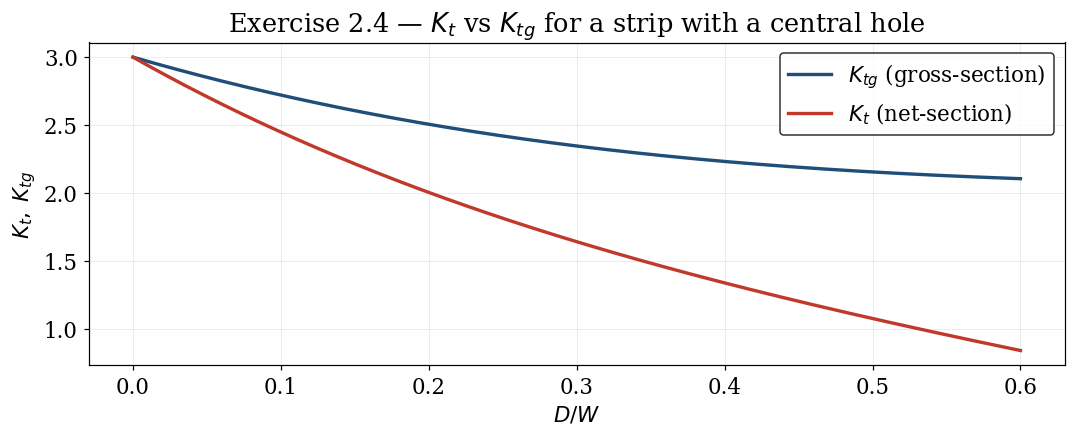

In [44]:
# Illustrate K_t vs K_tg as D/W varies
DW = np.linspace(0.0, 0.6, 400)
Ktg = howland_Ktg(DW)
Kt  = Ktg * (1.0 - DW)
fig, ax = plt.subplots()
ax.plot(DW, Ktg, color=COLORS['curve'], lw=2.2, label=r'$K_{tg}$ (gross-section)')
ax.plot(DW, Kt,  color=COLORS['point'], lw=2.2, label=r'$K_t$ (net-section)')
ax.set_xlabel(r'$D/W$'); ax.set_ylabel(r'$K_t,\;K_{tg}$')
ax.set_title('Exercise 2.4 — $K_t$ vs $K_{tg}$ for a strip with a central hole')
ax.legend(); plt.tight_layout(); plt.show()


<a id='ex5'></a>
---

## 2.5 — Stress field around a circular hole in an infinite plate

An infinite sheet containing a circular hole of diameter $D = 2a$ is loaded in uniaxial tension by a remote stress $S$ along the $y$-direction.

The classical Kirsch solution gives the tangential stress along the edge of the hole $(r=a)$ as

$$
\sigma_{\theta}(S,\theta)
=
S\left(1 + 2\cos 2\theta\right),
$$

where $\theta$ is measured from point A, located on the positive $x$-axis. Therefore, point A corresponds to $\theta = 0^\circ$, and point B corresponds to $\theta = 90^\circ$.

Along the $x$-axis, starting from point A and moving away from the hole, the normal stress component is

$$
\frac{\sigma_y(r)}{S}
= 1 + \frac{1}{2}\left(\frac{a}{r}\right)^2
+ \frac{3}{2}\left(\frac{a}{r}\right)^4,
\qquad r \geq a.
$$

The corresponding stress gradient at the edge of the hole is

$$
\left.\frac{d\sigma_y}{dr}\right|_{r=a} = - \frac{7S}{a}.
$$

(a) Using the tangential stress expression, determine the value of $K_t$ for a circular hole in an infinite plate.

(b) Compute the tangential stress $\sigma_\theta$ at the top of the hole, point B. Is this stress tensile or compressive?

(c) Describe qualitatively how the tangential stress $\sigma_\theta$ varies along the edge of the hole, from point A $(\theta = 0^\circ)$ to point B $(\theta = 90^\circ)$. At which angle does $\sigma_\theta$ become zero?

(d) Explain how the stress component $\sigma_y$ decays along the $x$-axis away from point A. Use the expression for $\sigma_y(r)$ and the stress gradient at the hole edge to comment on the rate of decay.

### Solution


#### (a) $K_t$ for a circular hole

The tangential stress (2.5.1) is maximum at $\theta=0$ (point A):

\begin{equation*}
\sigma_{\theta,\max} = S(1 + 2) = 3S \quad\Longrightarrow\quad K_t = 3.
\tag{2.5.4}\end{equation*}

#### (b) Tangential stress at point B ($\theta=90^\circ$)

\begin{equation*}
\sigma_{\theta}(90^\circ) = S(1 + 2\cos 180^\circ) = S(1-2) = -S.
\tag{2.5.5}\end{equation*}

**Compressive**: equal in magnitude to the remote tensile stress and of
opposite sign. (Schijve Ch. 5 highlights the same compressive feature on the
crack edges in (5.4a).)

#### (c) Variation of $\sigma_\theta$ from A to B

From $3S$ at $\theta=0$ to $-S$ at $\theta=90^\circ$. The zero is at
$2\cos 2\theta = -1$, i.e. $\cos 2\theta = -1/2$, $\theta = 60^\circ$.

#### (d) Decay along the $x$-axis

The dominant term $3(a/r)^4/2$ decays as $r^{-4}$ — very steep. At $r=a$ the
slope is $-7S/a$ (eq. 2.5.3). At $r=3a$ the amplification is already
essentially 1 (within ~6%). The stress concentration is *local*.


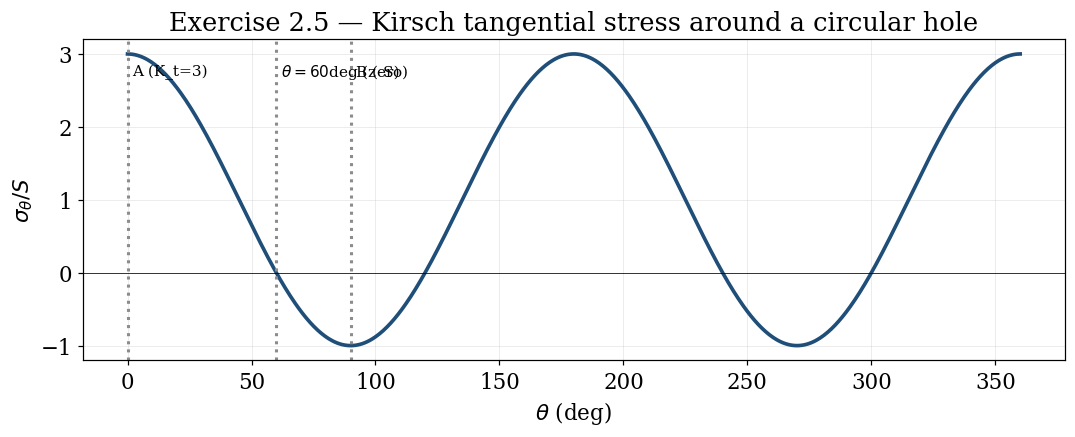

Verification of tangential stress:
  sigma_theta at A (theta=0):   1 + 2*cos(0)   = 3.000 S  (= 3S  => K_t = 3  ok)
  sigma_theta at B (theta=90): 1 + 2*cos(pi)  = -1.000 S  (= -S, compressive  ok)
  zero crossing: 1 + 2*cos(2*theta) = 0
    cos(2*theta) = -0.5  =>  2*theta = 120 deg  =>  theta = 60.0 deg  ok



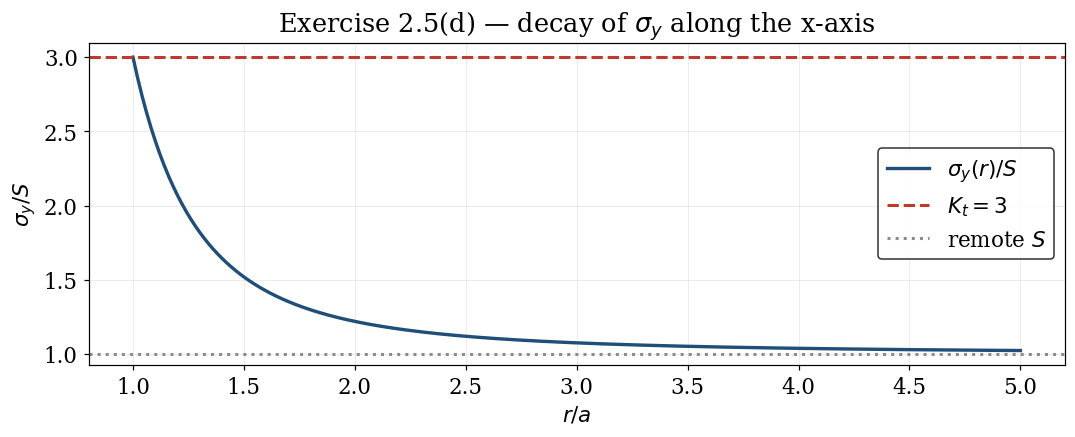

Decay of sigma_y along the x-axis:
  sigma_y at r = a   (r/a=1): 1 + 0.5 + 1.5  = 3.000 S  (= K_t*S  ok)
  sigma_y at r = 3a  (r/a=3): 1 + 0.5/9 + 1.5/81 = 1.0741 S  (close to remote S)
  numerical (d*sigma_y/dr)/S at r~a : -6.838  (theoretical -7)


In [45]:
# (a)-(c) tangential stress on the hole edge
theta = np.linspace(0, 2*np.pi, 720)
S = 1.0
sigma_theta = S * (1 + 2*np.cos(2*theta))

fig, ax = plt.subplots(figsize=(10,4.2))
ax.plot(np.degrees(theta), sigma_theta, color=COLORS['curve'], lw=2.4)
ax.axhline(0, color='k', lw=0.5)
for ang, lab in [(0, 'A (K_t=3)'), (90, 'B (-S)'), (60, '$\\theta=60$deg (zero)')]:
    ax.axvline(ang, color=COLORS['guide'], ls=':')
    ax.text(ang+2, 2.7, lab, fontsize=10)
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'$\sigma_\theta / S$')
ax.set_title('Exercise 2.5 — Kirsch tangential stress around a circular hole')
plt.tight_layout(); plt.show()

# Numerical verification of key values from the Kirsch solution
sigma_A = S * (1 + 2*np.cos(0))
sigma_B = S * (1 + 2*np.cos(np.pi))
theta_zero = np.degrees(np.arccos(-0.5) / 2)
print(f'Verification of tangential stress:')
print(f'  sigma_theta at A (theta=0):   1 + 2*cos(0)   = {sigma_A:.3f} S  (= 3S  => K_t = 3  ok)')
print(f'  sigma_theta at B (theta=90): 1 + 2*cos(pi)  = {sigma_B:.3f} S  (= -S, compressive  ok)')
print(f'  zero crossing: 1 + 2*cos(2*theta) = 0')
print(f'    cos(2*theta) = -0.5  =>  2*theta = {np.degrees(np.arccos(-0.5)):.0f} deg  =>  theta = {theta_zero:.1f} deg  ok')
print()

# (d) decay along x-axis
r_a = np.linspace(1.0, 5.0, 400)
sigma_y = S*(1 + 0.5/r_a**2 + 1.5/r_a**4)
fig, ax = plt.subplots()
ax.plot(r_a, sigma_y, color=COLORS['curve'], lw=2.2, label=r'$\sigma_y(r)/S$')
ax.axhline(3, ls='--', color=COLORS['point'], label='$K_t=3$')
ax.axhline(1, ls=':',  color=COLORS['guide'], label='remote $S$')
ax.set_xlabel(r'$r/a$'); ax.set_ylabel(r'$\sigma_y/S$')
ax.set_title('Exercise 2.5(d) — decay of $\\sigma_y$ along the x-axis')
ax.legend(); plt.tight_layout(); plt.show()

sigma_at_1a  = S*(1 + 0.5/1.0**2 + 1.5/1.0**4)
sigma_at_3a  = S*(1 + 0.5/3.0**2 + 1.5/3.0**4)
dsdr_num = (sigma_y[1] - sigma_y[0]) / (r_a[1] - r_a[0])
print(f'Decay of sigma_y along the x-axis:')
print(f'  sigma_y at r = a   (r/a=1): 1 + 0.5 + 1.5  = {sigma_at_1a:.3f} S  (= K_t*S  ok)')
print(f'  sigma_y at r = 3a  (r/a=3): 1 + 0.5/9 + 1.5/81 = {sigma_at_3a:.4f} S  (close to remote S)')
print(f'  numerical (d*sigma_y/dr)/S at r~a : {dsdr_num:.3f}  (theoretical -7)')


<a id='ex6'></a>
---

## 2.6 — Circular hole in a finite-width strip

A strip of width $W$ containing a central circular hole of diameter $D$ is loaded in uniaxial tension.

(a) Using the Howland approximation (the corresponding equation), sketch $K_t$ (net-section) as a function of $D/W$ for $0 \leq D/W \leq 0.6$. Identify the value of $D/W$ at which $K_t$ is a minimum and the corresponding minimum $K_t$ value.

(b) Explain why $K_t$ decreases for small $D/W$ (approaching the infinite-plate limit) and then increases again as $D/W$ grows (why does $K_t$ eventually rise?).

(c) **Numerical application:** A strip has the following dimensions: $W = 60$ mm, $D = 10$ mm, thickness $t = 5$ mm. The strip is loaded with $P = 50$ kN.

(i) Compute $K_{tg}$ and $K_t$ for this geometry.

(ii) Determine the peak stress $\sigma_{\text{peak}}$ at the edge of the hole.

(d) Does $K_t$ depend on the applied load $P$? Justify.

### Solution


#### (a) Plot of $K_t(D/W)$ and its minimum

Using the Howland approximation (F.5)–(F.6).


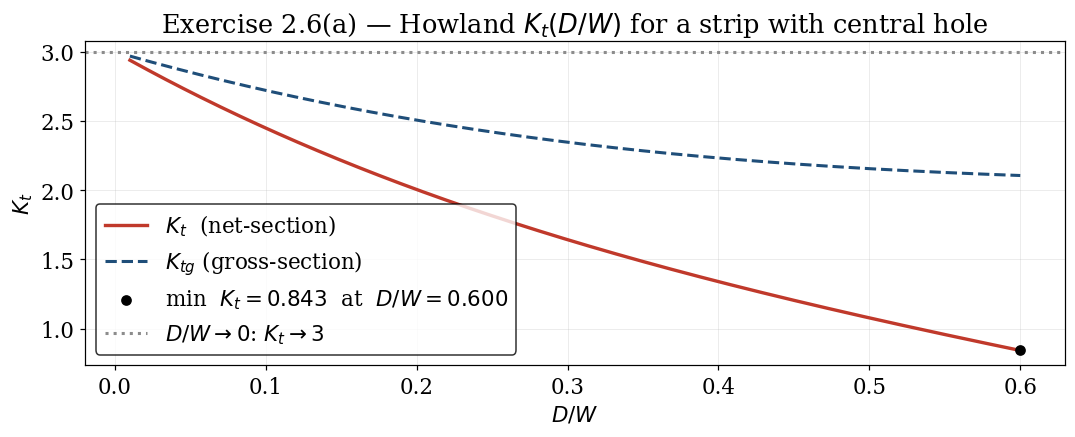

    minimum K_t = 0.843  at  D/W = 0.600


In [46]:
DW = np.linspace(0.01, 0.60, 600)
Ktg, Kt = howland_Ktg(DW), net_Kt(DW)
idx_min = np.argmin(Kt)
DW_min, Kt_min = DW[idx_min], Kt[idx_min]

fig, ax = plt.subplots()
ax.plot(DW, Kt,  color=COLORS['point'], lw=2.2, label=r'$K_t$  (net-section)')
ax.plot(DW, Ktg, color=COLORS['curve'], lw=2.0, ls='--', label=r'$K_{tg}$ (gross-section)')
ax.scatter([DW_min], [Kt_min], color='black', zorder=5,
           label=fr'min  $K_t={Kt_min:.3f}$  at  $D/W={DW_min:.3f}$')
ax.axhline(3, color=COLORS['guide'], ls=':', label=r'$D/W\to 0$: $K_t\to 3$')
ax.set_xlabel(r'$D/W$'); ax.set_ylabel(r'$K_t$')
ax.set_title('Exercise 2.6(a) — Howland $K_t(D/W)$ for a strip with central hole')
ax.legend(); plt.tight_layout(); plt.show()
print(f'    minimum K_t = {Kt_min:.3f}  at  D/W = {DW_min:.3f}')


#### (b) Why a non-monotonic curve?

* For $D/W\to 0$ the strip is effectively infinite and $K_t\to 3$ (the Kirsch
  limit of Exercise 2.5).
* As the hole grows, the *peak* stress increases only modestly, but the
  net-section area shrinks. Because $K_t$ is normalised by the **net-section**
  nominal stress, the rapidly rising $\sigma_{\text{net}}$ initially out-runs
  the small rise of $\sigma_{\text{peak}}$ and $K_t$ **decreases**.
* For larger $D/W$ the proximity of the hole to the free edges produces an
  additional ligament-bending component that drives $\sigma_{\text{peak}}$
  upward faster than the geometric loss of net section — $K_t$ **rises again**.

#### (c) Numerical application

Data: $W=60$ mm, $D=10$ mm, $t=5$ mm, $P=50$ kN.


In [47]:
W, D, t, P = 60.0, 10.0, 5.0, 50e3       # mm, mm, mm, N
DW0   = D/W
Ktg0  = howland_Ktg(DW0)
Kt0   = net_Kt(DW0)

A_gross = W*t                                          # mm^2
A_net   = (W - D)*t
sigma_gross = P/A_gross                                # MPa
sigma_net   = P/A_net
sigma_peak  = Kt0 * sigma_net                          # = Ktg0 * sigma_gross

print(f'  D/W = {D:.0f}/{W:.0f} = {DW0:.4f}')
print()
print(f'  Howland: K_tg = 3 - 3.14*(D/W) + 3.667*(D/W)^2 - 1.527*(D/W)^3')
print(f'         = 3 - 3.14x{DW0:.4f} + 3.667x{DW0**2:.6f} - 1.527x{DW0**3:.6f}')
print(f'         = {3:.4f} - {3.14*DW0:.4f} + {3.667*DW0**2:.4f} - {1.527*DW0**3:.4f}')
print(f'         = {Ktg0:.3f}')
print(f'  K_t = K_tg x (1 - D/W) = {Ktg0:.3f} x (1 - {DW0:.4f}) = {Ktg0:.3f} x {1-DW0:.4f} = {Kt0:.3f}')
print()
print(f'  A_gross = W x t = {W:.0f} x {t:.0f} = {A_gross:.0f} mm^2')
print(f'  A_net   = (W-D) x t = ({W:.0f}-{D:.0f}) x {t:.0f} = {A_net:.0f} mm^2')
print()
print(f'  sigma_gross = P/A_gross = {P:.0f}/{A_gross:.0f} = {sigma_gross:.2f} MPa')
print(f'  sigma_net   = P/A_net   = {P:.0f}/{A_net:.0f} = {sigma_net:.2f} MPa')
print()
print(f'  sigma_peak = K_t x sigma_net = {Kt0:.3f} x {sigma_net:.2f} = {sigma_peak:.2f} MPa')
print(f'  Check: K_tg x sigma_gross = {Ktg0:.3f} x {sigma_gross:.2f} = {Ktg0*sigma_gross:.2f} MPa  ok')


  D/W = 10/60 = 0.1667

  Howland: K_tg = 3 - 3.14*(D/W) + 3.667*(D/W)^2 - 1.527*(D/W)^3
         = 3 - 3.14x0.1667 + 3.667x0.027778 - 1.527x0.004630
         = 3.0000 - 0.5233 + 0.1019 - 0.0071
         = 2.571
  K_t = K_tg x (1 - D/W) = 2.571 x (1 - 0.1667) = 2.571 x 0.8333 = 2.143

  A_gross = W x t = 60 x 5 = 300 mm^2
  A_net   = (W-D) x t = (60-10) x 5 = 250 mm^2

  sigma_gross = P/A_gross = 50000/300 = 166.67 MPa
  sigma_net   = P/A_net   = 50000/250 = 200.00 MPa

  sigma_peak = K_t x sigma_net = 2.143 x 200.00 = 428.58 MPa
  Check: K_tg x sigma_gross = 2.571 x 166.67 = 428.58 MPa  ok


#### (d) Does $K_t$ depend on $P$?

No. $K_t$ is purely geometric: $K_t = \sigma_{\text{peak}}/\sigma_{\text{nom}}$
and both stresses scale **linearly** with $P$ (linear elasticity). So the
ratio is invariant under load. $P$ only sets the *magnitude* of the peak
stress, not the amplification factor.


<a id='ex7'></a>
---

## 2.7 — Elliptical hole and the transition to a crack

An infinite plate is loaded in uniaxial tension (stress $S$) and contains an elliptical hole with semi-axes $a$ (perpendicular to the load) and $b$ (parallel to the load).

(a) Write the expression for $K_t$ of the elliptical hole (Inglis solution) and verify that for $a = b$ (circular hole) it recovers $K_t = 3$.

(b) Rewrite $K_t$ as a function of $a$ and the tip radius $\rho = b^2/a$. Show that this is equivalent to the Creager–Paris formula.

(c) Plot (or sketch) $K_t$ as a function of $a/b$ for $a/b \in [1,\,20]$. Comment on what happens as the ellipse becomes increasingly elongated ($a/b \to \infty$, $\rho \to 0$): why does the concept of $K_t$ become impractical, and what parameter replaces it?

### Solution


#### (a)–(b) Inglis $\leftrightarrow$ Creager–Paris equivalence

From (F.4),

\begin{equation*}
K_t = 1 + 2\dfrac{a}{b}\quad\Longrightarrow\quad a=b\Rightarrow K_t=3.\;\checkmark
\tag{2.7.1}\end{equation*}

With $\rho = b^{2}/a$, i.e. $b/a = \sqrt{\rho/a}$,

\begin{equation*}
K_t = 1 + 2\,\dfrac{a}{b} = 1 + 2\sqrt{a/\rho},
\tag{2.7.2}\end{equation*}

which is exactly the Creager–Paris form (F.2). Inglis and Creager–Paris are
the same statement in two different parameterisations.


In [48]:
# Symbolic check
a_s, b_s, rho_s = sy.symbols('a b rho', positive=True)
Kt_inglis  = 1 + 2*a_s/b_s
rho_def    = sy.Eq(rho_s, b_s**2 / a_s)
b_in_rho   = sy.solve(rho_def, b_s)[0]                # = sqrt(rho a)
Kt_creager = sy.simplify(Kt_inglis.subs(b_s, b_in_rho))
print('Inglis:  K_t =', Kt_inglis)
print('Substitute  b = sqrt(ρ·a)  →  K_t =', Kt_creager)


Inglis:  K_t = 2*a/b + 1
Substitute  b = sqrt(ρ·a)  →  K_t = 2*sqrt(a)/sqrt(rho) + 1


#### (c) Plot of $K_t$ vs $a/b$

As $a/b\to\infty$ the ellipse degenerates into a crack: $\rho\to 0$,
$K_t\to\infty$. The notion of $K_t$ loses operational value and must be
replaced by the stress intensity factor $K$ (Schijve §5.1).


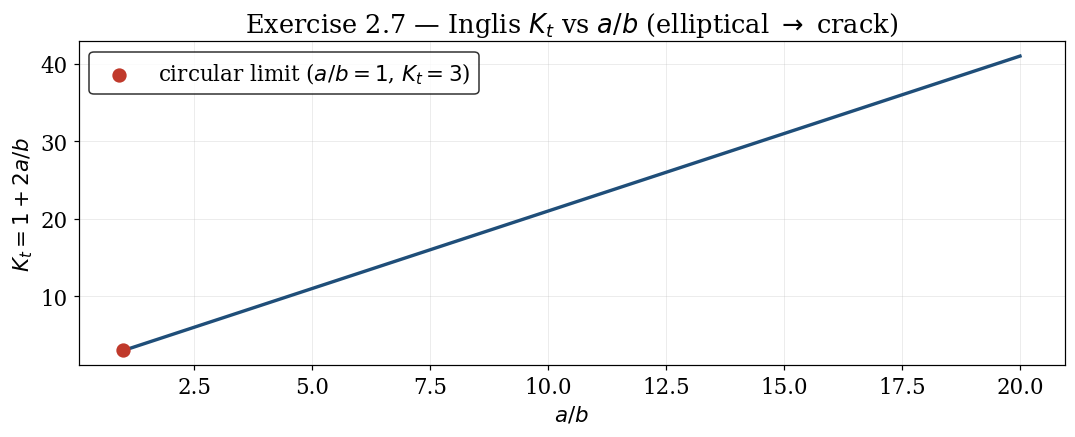

In [49]:
ab = np.linspace(1, 20, 400)
Kt = 1 + 2*ab
fig, ax = plt.subplots()
ax.plot(ab, Kt, color=COLORS['curve'], lw=2.2)
ax.scatter([1], [3], color=COLORS['point'], s=70, zorder=5,
           label='circular limit ($a/b=1$, $K_t=3$)')
ax.set_xlabel(r'$a/b$'); ax.set_ylabel(r'$K_t = 1 + 2a/b$')
ax.set_title('Exercise 2.7 — Inglis $K_t$ vs $a/b$ (elliptical $\\to$ crack)')
ax.legend(); plt.tight_layout(); plt.show()


<a id='ex8'></a>
---

## 2.8 — Notch sensitivity and $K_f$

The fatigue strength reduction factor $K_f$ is typically smaller than the elastic stress concentration factor $K_t$, reflecting the fact that not all of the stress concentration translates into an equivalent reduction in fatigue strength.

(a) Define the notch sensitivity factor $q$ and explain the meaning of the limits $q = 0$ and $q = 1$.

(b) Is the fact that $K_f < K_t$ favourable for the designer? Why does this difference arise from a physical standpoint (consider the stress gradient at the notch root and the microstructural scale of crack initiation)?

(c) Compare the notch sensitivity of a low-strength steel with that of a high-strength steel. Which material is more notch-sensitive? Briefly explain why.

(d) The prediction of the fatigue limit of a notched component is usually based on a comparison with the fatigue limit of unnotched material (the *similarity concept*). Discuss possible limitations of this approach.

### Solution

#### (a) Definition of $q$ and limits

\begin{equation*}
q = \dfrac{K_f-1}{K_t-1},\qquad K_f = 1 + q(K_t-1).
\tag{2.8.1}\end{equation*}

* $q=0$ — material is **fully insensitive** to the notch: $K_f=1$, the
  fatigue limit is unaffected.
* $q=1$ — material is **fully sensitive**: $K_f=K_t$, the elastic theory
  applies as-is.

Real materials sit between the two. Cast irons and very soft steels are
typically not very notch-sensitive ($q\sim 0.2$–$0.5$); high-strength alloys
and ceramics tend to be highly notch-sensitive ($q\sim 0.8$–$1.0$).

#### (b) Why is $K_f<K_t$ favourable, and where does it come from?

Favourable: a smaller effective amplification factor means a *higher*
predicted fatigue strength for the notched component.

Physical origin: the elastic peak $\sigma_{\text{peak}}=K_t\sigma_{\text{nom}}$ is
reached at a single mathematical point. Fatigue crack initiation requires the
formation of slip bands over a microstructural scale (grain size, dislocation
cell size). Because the stress gradient $d\sigma/dr$ at the notch root is
**steep**, the average stress over that small but finite scale is **lower**
than the point peak — hence the effective amplification factor $K_f$ is less
than $K_t$. Sharper notches have steeper gradients and lower $q$; gentler
notches approach $q\to 1$.

#### (c) Low-strength vs. high-strength steel

High-strength steels are **more** notch-sensitive. Their fatigue mechanism is
controlled by very small slip-band-scale defects, so the spatial averaging
over a microstructural length is essentially the *same* as the point peak.
Low-strength steels mobilise plasticity over a larger volume, redistributing
the peak and lowering $q$.

#### (d) Limitations of the similarity-based prediction

* It calibrates on unnotched specimens of the *same* material, but the
  notched component's surface condition, residual stresses and stress
  multiaxiality differ.
* $q$ depends on the geometry (notch radius, gradient), not only on the
  material.
* Mean-stress effects at the notch root (Neuber-type plasticity) are not
  captured by a single linear $K_f$.


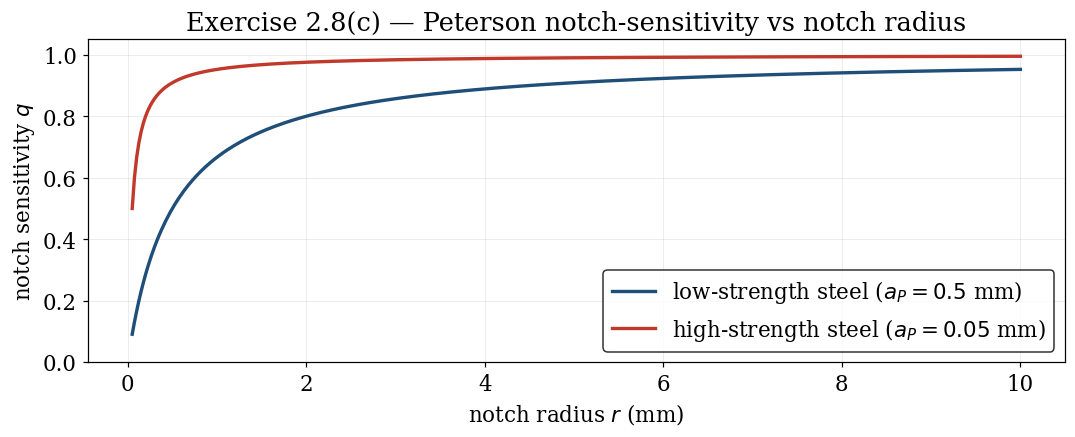

In [50]:
# Peterson-style notch sensitivity (qualitative) — Peterson's equation:
#   q = 1 / (1 + a_P/r)  where a_P depends on the material (Peterson length).
# Plot q(r) for two values of a_P illustrating low- and high-strength steels.
r_mm = np.linspace(0.05, 10, 400)
a_low, a_high = 0.50, 0.05         # representative Peterson lengths
q_low  = 1.0/(1.0 + a_low/r_mm)
q_high = 1.0/(1.0 + a_high/r_mm)

fig, ax = plt.subplots()
ax.plot(r_mm, q_low,  color=COLORS['curve'], lw=2.2,
        label=r'low-strength steel ($a_P=0.5$ mm)')
ax.plot(r_mm, q_high, color=COLORS['point'], lw=2.2,
        label=r'high-strength steel ($a_P=0.05$ mm)')
ax.set_xlabel(r'notch radius $r$ (mm)')
ax.set_ylabel(r'notch sensitivity $q$')
ax.set_title('Exercise 2.8(c) — Peterson notch-sensitivity vs notch radius')
ax.set_ylim(0, 1.05); ax.legend(); plt.tight_layout(); plt.show()


<a id='ex9'></a>
---

## 2.9 — Surface finish, size effects and fatigue

Answer the following conceptual questions.

(a) Size effects on fatigue can occur in notched components. What is the "relevant size" of the notch that governs this effect? Are the prediction methods for size effects on fatigue fundamentally rational or empirical?

(b) Compare the significance of surface finish for: (i) the fatigue limit, (ii) high-cycle fatigue life, and (iii) low-cycle fatigue life. In which regime is surface finish most critical, and why?

(c) Explain why a fully rational procedure to predict the complete S–N curve of a notched component does not currently exist, despite the availability of accurate $K_t$ values.

### Solution

#### (a) Relevant size

For a notch, the "relevant size" is the **notch-root radius $\rho$** (or
equivalently the local stress-gradient length, $\sigma/(d\sigma/dr)$ at
the root). It controls the volume over which the high-stress field acts —
hence the probability of finding a critical defect inside that volume.

Empirical models (Peterson, Neuber, Siebel–Stieler) link $K_f/K_t$ to
$\rho$ via a material length. They are **empirical**, not rational: they
fit experimental data but do not derive from first principles.

#### (b) Surface finish

* **Fatigue limit ($N\sim 10^{6}$–$10^{8}$):** surface finish is **critical**.
  Microscale roughness is enough to seed slip bands; the fatigue limit can
  drop by 30–60 % between polished and as-machined finish.
* **High-cycle finite life ($N\sim 10^{5}$–$10^{6}$):** surface finish is
  important but less decisive — the larger plasticity at the notch root
  smooths out small surface irregularities.
* **Low-cycle fatigue ($N<10^{4}$):** surface finish has **little** effect.
  Bulk plastic strain dominates; the crack-initiation life is short and
  controlled by Coffin–Manson, not by surface microcracks.

#### (c) Why a rational S–N prediction for notched parts is still missing

Even with an accurate $K_t$, the full S–N curve depends on at least four
non-trivial ingredients:

1. The transition from elastic to elastoplastic notch-root behaviour
   (Neuber/strain-life formalism).
2. The effective $K_f$, which depends on geometry and material in a
   non-universal way.
3. The interaction with surface condition and residual stress.
4. The statistical distribution of defects at the most stressed volume.

Each of these is parameterised empirically, so a single closed-form
prediction is not yet possible.


<a id='ex10'></a>
---

## 2.10 — Stress concentration under biaxial loading

(a) Consider an open hole in a large plate loaded under *pure shear*. What is the value of $K_t$ in this case? Is the loading at the critical point on the hole edge uniaxial or biaxial?

(b) A large sheet with a circular hole is subjected to biaxial tension with principal stresses $S_1$ (horizontal) and $S_2 = \beta S_1$ (vertical), where $\beta = 0.5$ is the biaxiality ratio. The stresses are applied fully in phase (synchronised).

(i) Using the superposition principle, determine the tangential stress at the critical point (point A, where the stress is maximum) in terms of $S_1$.

(ii) Now consider the case where $S_1$ and $S_2$ are *not* synchronised: $S_1$ cycles between 0 and $S_1^{\max}$ while $S_2 = \beta S_1^{\max}$ is constant (static). Determine the stress range at point A.

(c) Comment on why the synchronisation of the biaxial loading is important for fatigue assessment.

### Solution

#### (a) Open hole under pure shear

In pure shear $\tau$, equivalent to biaxial $S_1=+\tau$, $S_2=-\tau$ rotated
by 45°. By superposition of two Kirsch fields on an infinite plate with a
circular hole, the maximum tangential stress at the hole edge becomes

\begin{equation*}
\sigma_{\theta}^{\,\max} = 4\tau \quad\Longrightarrow\quad K_t = 4
\;(\text{relative to }\tau).
\tag{2.10.1}\end{equation*}

The point of maximum stress is at $\theta=45^\circ$ from the direction of
$S_1$, and the loading at that point is **uniaxial** (the two principal
contributions cancel in the radial direction and add tangentially).

#### (b-i) Synchronised biaxial tension, $S_2=\beta S_1$, $\beta=0.5$

Superposition of Kirsch:

\begin{equation*}
\sigma_\theta^A = S_1(1+2\cos 2\theta) + S_2(1+2\cos 2(\theta-90^\circ)),
\tag{2.10.2}\end{equation*}

At point A ($\theta=0$, perpendicular to $S_1$):

\begin{equation*}
\sigma_\theta^A = S_1(1+2) + S_2(1-2) = 3S_1 - S_2 = (3-\beta)\,S_1.
\tag{2.10.3}\end{equation*}

For $\beta=0.5$, $\sigma_\theta^A = 2.5\,S_1$ — the second principal stress
*reduces* the concentration at A relative to the uniaxial case ($K_t=3$).

#### (b-ii) Non-synchronised case ($S_2$ static, $S_1$ pulsating)

\begin{equation*}
\sigma_\theta^A(t) = 3 S_1(t) - S_2 = 3S_1(t) - 0.5 S_1^{\max}.
\tag{2.10.4}\end{equation*}

* $S_1(t)=0$: $\sigma_\theta^A = -0.5\,S_1^{\max}$
* $S_1(t)=S_1^{\max}$: $\sigma_\theta^A = 2.5\,S_1^{\max}$
* Stress range: $\Delta\sigma_\theta = 3\,S_1^{\max}$, which is **larger**
  than the synchronised case (also $3 S_1^{\max}$ peak, but mean stress
  differs).

#### (c) Why phase matters for fatigue

The damaging fatigue parameters are the **range** $\Delta\sigma$ and **mean**
$\sigma_m$ at the critical point. Two loadings with the same $S_1^{\max}$
but different phase relations between $S_1$ and $S_2$ generate different
$(\Delta\sigma,\sigma_m)$ at A; a non-synchronised mean stress can shift
the operating point into a more (or less) damaging region of the
Goodman/Soderberg diagram.


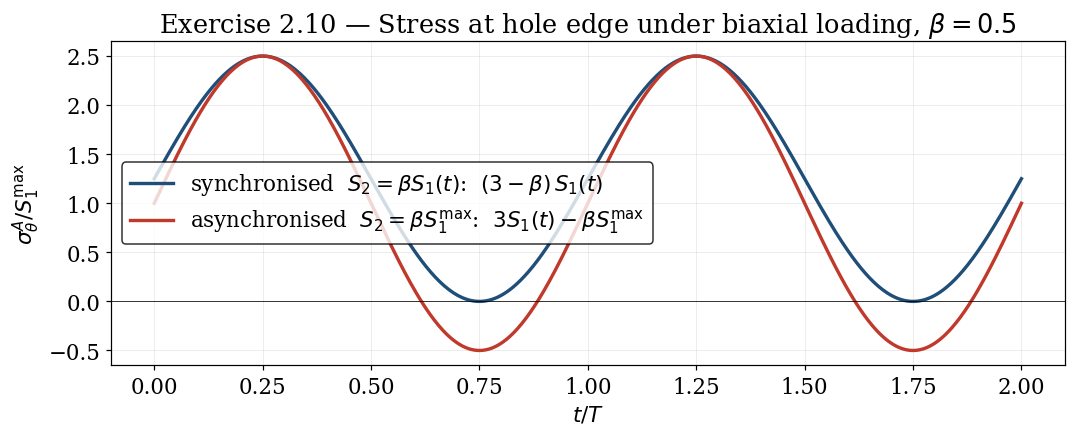

Synchronised (S2 = beta*S1(t), beta=0.5):
  sigma_theta(t) = 3*S1(t) - S2(t) = 3*S1(t) - 0.5*S1(t) = (3-0.5)*S1(t) = 2.5*S1(t)
  max = 2.5*S1_max = 2.500*S1_max  (at S1=S1_max)
  min = 2.5*0 = 0.000*S1_max           (at S1=0)
  Delta_sigma_theta = 2.500*S1_max,   sigma_m = 1.250*S1_max

Asynchronised (S2 = beta*S1_max = 0.5*S1_max = const):
  sigma_theta(t) = 3*S1(t) - 0.5*S1_max
  max (at S1=S1_max): 3*1.0 - 0.5 = 2.500*S1_max
  min (at S1=0):      3*0 - 0.5 = -0.500*S1_max
  Delta_sigma_theta = 3.000*S1_max,   sigma_m = 1.000*S1_max


In [51]:
# (b) Compare synchronised vs. non-synchronised at point A
beta = 0.5
S1_max = 1.0

t = np.linspace(0, 2, 600)
S1_sync = S1_max*(np.sin(2*np.pi*t)*0.5 + 0.5)          # pulsating 0..S1_max
S1_pls  = S1_sync.copy()                                # same waveform

S2_sync = beta*S1_sync                                  # in-phase
S2_stat = beta*S1_max*np.ones_like(t)                   # constant

sig_sync  = 3*S1_sync - S2_sync                         # = (3-beta)*S1(t)
sig_async = 3*S1_pls  - S2_stat

fig, ax = plt.subplots(figsize=(10,4.2))
ax.plot(t, sig_sync,  color=COLORS['curve'], lw=2.2,
        label=r'synchronised  $S_2=\beta S_1(t)$:  $(3-\beta)\,S_1(t)$')
ax.plot(t, sig_async, color=COLORS['point'], lw=2.2,
        label=r'asynchronised  $S_2=\beta S_1^{\max}$:  $3S_1(t)-\beta S_1^{\max}$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$t / T$'); ax.set_ylabel(r'$\sigma_\theta^A / S_1^{\max}$')
ax.set_title(r'Exercise 2.10 — Stress at hole edge under biaxial loading, $\beta=0.5$')
ax.legend(); plt.tight_layout(); plt.show()

dr_sync  = sig_sync.max()  - sig_sync.min()
dr_async = sig_async.max() - sig_async.min()
m_sync   = (sig_sync.max()  + sig_sync.min())/2
m_async  = (sig_async.max() + sig_async.min())/2

print(f'Synchronised (S2 = beta*S1(t), beta={beta}):')
print(f'  sigma_theta(t) = 3*S1(t) - S2(t) = 3*S1(t) - {beta}*S1(t) = (3-{beta})*S1(t) = {3-beta}*S1(t)')
print(f'  max = {3-beta}*S1_max = {(3-beta)*S1_max:.3f}*S1_max  (at S1=S1_max)')
print(f'  min = {3-beta}*0 = 0.000*S1_max           (at S1=0)')
print(f'  Delta_sigma_theta = {dr_sync:.3f}*S1_max,   sigma_m = {m_sync:.3f}*S1_max')
print()
print(f'Asynchronised (S2 = beta*S1_max = {beta*S1_max}*S1_max = const):')
print(f'  sigma_theta(t) = 3*S1(t) - {beta*S1_max}*S1_max')
print(f'  max (at S1=S1_max): 3*{S1_max} - {beta*S1_max} = {3*S1_max - beta*S1_max:.3f}*S1_max')
print(f'  min (at S1=0):      3*0 - {beta*S1_max} = {-beta*S1_max:.3f}*S1_max')
print(f'  Delta_sigma_theta = {dr_async:.3f}*S1_max,   sigma_m = {m_async:.3f}*S1_max')


---

### Final remarks

* All numerical results follow from the four classical solutions in the
  formulary at the top: Creager–Paris (F.2), Inglis (F.4), Howland (F.5), and
  Kirsch (Exercise 2.5).
* The notch-sensitivity factor $q$ and the fatigue strength reduction factor
  $K_f$ are *empirical* corrections that translate the elastic
  $K_t$ into a fatigue-relevant amplification (Exercise 2.8).
* The infinite-stress limit at a sharp crack ($\rho\to 0$) motivates the
  Linear Elastic Fracture Mechanics framework treated in the next problem
  set (P03), where $K$ replaces $K_t$.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.